In [ ]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import rasterio
import rioxarray as rxr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import string

c:\Users\Clemens\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Local input and output paths
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "07_postprocess_data" / "local" / "species_richness_from_SDM_projections" / "data" / "results_mean_ETresid").is_dir()
)
base_path = (
    repository_root
    / "07_postprocess_data"
    / "local"
    / "species_richness_from_SDM_projections"
    / "data"
    / "results_mean_ETresid"
)
plot_dir = repository_root / "08_figures" / "main_figures" / "figure_2" / "output"
plot_dir.mkdir(parents=True, exist_ok=True)

# Define ssp
ssp = "ssp245"

# Scenarios and time periods
scenarios = [
    {"name": f"{ssp}_notip_no_deforestation", "label": "no tip", "type": "notip"},
    {"name": f"{ssp}_tip_no_deforestation", "label": "tip + no defor", "type": "tip_no_defor"},
    {"name": f"{ssp}_tip_deforestation", "label": "tip + defor", "type": "tip_defor"},
]

time_periods = ["2030_2044", "2050_2069", "2080_2099"]

# Species groups
species_groups = ["amphibians", "mammals", "reptiles", "birds_resident"]

def fname(prefix, group):
    """Return the mean species-richness filename for one group."""
    return f"{prefix}_species_richness_mean_{group}.tif"


In [3]:
rasters = {
    "historic": {},
    "future": {},
    "delta": {}
}

for sc in scenarios:
    scen_name = sc["name"]

    for tp in time_periods:
        key = f"{scen_name}_{tp}"

        rasters["historic"][key] = {}
        rasters["future"][key] = {}
        rasters["delta"][key] = {}

        for group in species_groups:
            paths = {
                "historic": os.path.join(
                    base_path, scen_name, tp,
                    fname("historic", group)
                ),
                "future": os.path.join(
                    base_path, scen_name, tp,
                    fname("future", group)
                ),
                "delta": os.path.join(
                    base_path, scen_name, tp,
                    fname("delta", group)
                ),
            }

            for kind, path in paths.items():
                if not os.path.exists(path):
                    print("File not found:", path)
                    continue

                rasters[kind][key][group] = path


In [4]:
# Sum species richness across all groups 
for sc in scenarios:
    scen_name = sc["name"]

    for tp in time_periods:
        key = f"{scen_name}_{tp}"

        for kind in ["historic", "future", "delta"]:
            group_paths = rasters[kind].get(key, {})

            if len(group_paths) == 0:
                continue

            summed = None
            valid_count = None
            profile = None

            for group, path in group_paths.items():
                with rasterio.open(path) as src:
                    data = src.read(1).astype("float32")

                    if summed is None:
                        summed = np.zeros_like(data)
                        valid_count = np.zeros_like(data, dtype="uint8")
                        profile = src.profile

                    valid_mask = ~np.isnan(data)
                    summed[valid_mask] += data[valid_mask]
                    valid_count[valid_mask] += 1

            # Set pixels with NO valid species to NaN
            summed[valid_count == 0] = np.nan

            out_name = f"{kind}_species_richness_mean_all_species.tif"
            out_path = os.path.join(base_path, scen_name, tp, out_name)

            profile.update(dtype="float32", count=1, nodata=np.nan)

            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(summed, 1)

            print("Written:", out_path)


Written: C:\Users\Clemens\Desktop\amazon_code_public\07_postprocess_data\local\species_richness_from_SDM_projections\data\results_mean_ETresid\ssp245_notip_no_deforestation\2030_2044\historic_species_richness_mean_all_species.tif
Written: C:\Users\Clemens\Desktop\amazon_code_public\07_postprocess_data\local\species_richness_from_SDM_projections\data\results_mean_ETresid\ssp245_notip_no_deforestation\2030_2044\future_species_richness_mean_all_species.tif
Written: C:\Users\Clemens\Desktop\amazon_code_public\07_postprocess_data\local\species_richness_from_SDM_projections\data\results_mean_ETresid\ssp245_notip_no_deforestation\2030_2044\delta_species_richness_mean_all_species.tif
Written: C:\Users\Clemens\Desktop\amazon_code_public\07_postprocess_data\local\species_richness_from_SDM_projections\data\results_mean_ETresid\ssp245_notip_no_deforestation\2050_2069\historic_species_richness_mean_all_species.tif
Written: C:\Users\Clemens\Desktop\amazon_code_public\07_postprocess_data\local\specie

In [5]:
# Compute global min/max across ALL-SPECIES rasters

def global_min_max(file_list, cast_int=False):
    vals = []

    for fpath in file_list:
        if not os.path.exists(fpath):
            continue

        with rasterio.open(fpath) as src:
            arr = src.read(1, masked=True)
            vals.append(arr.min())
            vals.append(arr.max())

    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)

    if cast_int:
        vmin = int(vmin)
        vmax = int(vmax)

    return float(vmin), float(vmax)


# Collect all-species raster paths

hist_files = []
fut_files = []
delta_files = []

for sc in scenarios:
    scen_name = sc["name"]

    for tp in time_periods:
        base = os.path.join(base_path, scen_name, tp)

        hist_files.append(
            os.path.join(base, "historic_species_richness_mean_all_species.tif")
        )
        fut_files.append(
            os.path.join(base, "future_species_richness_mean_all_species.tif")
        )
        delta_files.append(
            os.path.join(base, "delta_species_richness_mean_all_species.tif")
        )

# Compute global min/max
hist_min, hist_max = global_min_max(hist_files)
print("Global historic min/max:", hist_min, hist_max)

fut_min, fut_max = global_min_max(fut_files)
print("Global future min/max:", fut_min, fut_max)

delta_min, delta_max = global_min_max(delta_files, cast_int=True)
print("Global delta min/max:", delta_min, delta_max)


Global historic min/max: 78.69999694824219 1103.0400390625
Global future min/max: 60.900001525878906 1086.449951171875
Global delta min/max: -563.0 173.0


In [ ]:
data = {}

# Bounding box
minx, miny, maxx, maxy = -80, -20, -50, 5

for sc in scenarios:
    scen_name = sc["name"]
    data[scen_name] = {}

    for tp in time_periods:
        base = os.path.join(base_path, scen_name, tp)

        f_hist  = os.path.join(base, "historic_species_richness_mean_all_species.tif")
        f_fut   = os.path.join(base, "future_species_richness_mean_all_species.tif")
        f_delta = os.path.join(base, "delta_species_richness_mean_all_species.tif")

        # Load
        hist_da  = rxr.open_rasterio(f_hist).squeeze()
        fut_da   = rxr.open_rasterio(f_fut).squeeze()
        delta_da = rxr.open_rasterio(f_delta).squeeze()

        hist_da = hist_da 
        fut_da  = fut_da 
        
        # Clip to bounding box
        hist_da  = hist_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
        fut_da   = fut_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
        delta_da = delta_da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

        # Store cleanly
        data[scen_name][tp] = {
            "historic": hist_da,
            "future": fut_da,
            "delta": delta_da,
        }


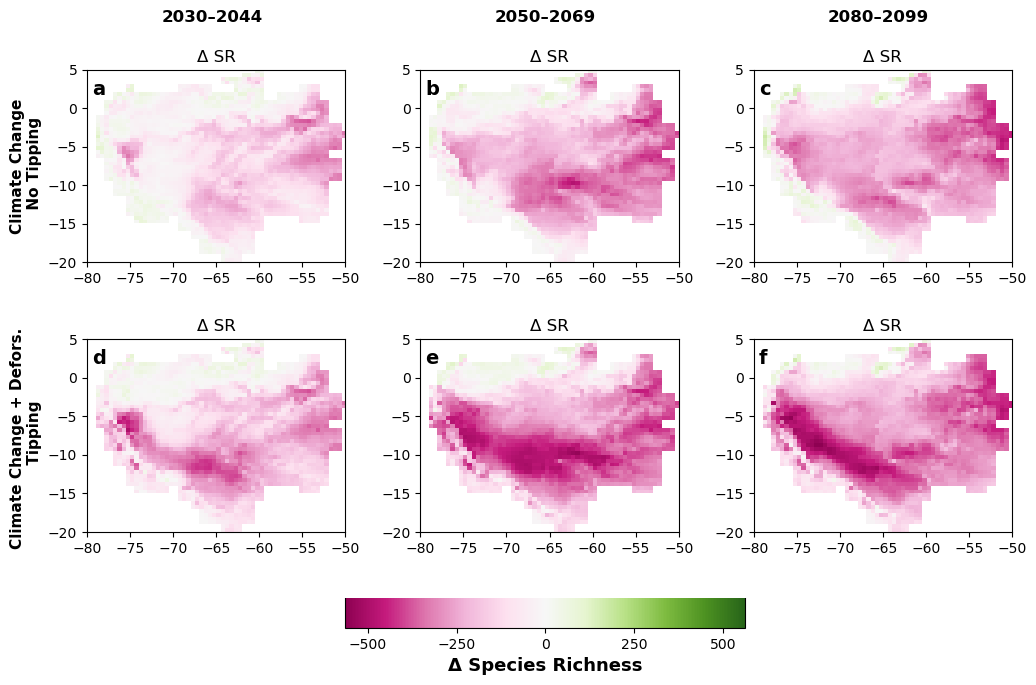

In [ ]:
# Scenarios (rows)
scenario_order = [
    f"{ssp}_notip_no_deforestation",
    f"{ssp}_tip_deforestation"
]

# Time periods (columns)
time_order = ["2030_2044", "2050_2069", "2080_2099"]
col_titles = ["2030–2044", "2050–2069", "2080–2099"]

y_labels = ["Climate Change\n No Tipping", "Climate Change + Defors. \n Tipping"]

# Delta normalization
delta_norm = mcolors.TwoSlopeNorm(
    vmin=delta_min,
    vcenter=0,
    vmax=-delta_min
)

fig = plt.figure(figsize=(10, 6))
subfigs = fig.subfigures(1, 3)
subfigs[0].subplots_adjust(hspace=0.4)
axs_list = [subfigs[i].subplots(2, 1) for i in range(3)]

# Historic reference period
hist_tp = time_order[0]

for s, scen_name in enumerate(scenario_order):

    # y-axis label
    part_1, part_2 = scen_name.replace(f"{ssp}_", "").split("_", 1)
    y_label = y_labels[s]

    for i, tp in enumerate(time_order):
        subfigs[i].suptitle(col_titles[i], fontweight="bold")

        delta_data = data[scen_name][tp]["delta"]
        hist_data  = data[scen_name][hist_tp]["historic"]

        # Optional: percentage change
        #prec_change_data = delta_data / hist_data.where(hist_data != 0)

        # Plot delta SR (all species)
        im = delta_data.plot.imshow(
            ax=axs_list[i][s],
            cmap="PiYG",
            norm=delta_norm,
            add_colorbar=False
        )

        axs_list[i][s].set_title("Δ SR")
        axs_list[i][s].set_xlabel("")

        if i == 0:
            axs_list[i][s].set_ylabel(y_label, fontsize=11, fontweight="bold")
        else:
            axs_list[i][s].set_ylabel("")

# Colorbar
cbar_ax = fig.add_axes([0.3, -0.05, 0.4, 0.1])
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")

cbar.set_label("Δ Species Richness", fontsize=13, fontweight="bold")
cbar.set_ticks([-500, -250,  0, 250, 500])

import string
panel_letters = list(string.ascii_lowercase[:6])

letter_idx = 0

for row in range(2):          
    for col in range(3):      
        ax = axs_list[col][row]
        ax.text(
            0.02, 0.95,
            panel_letters[letter_idx],
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left"
        )
        letter_idx += 1


plt.savefig(
    os.path.join(plot_dir, f"{ssp}_final_figure_2.png"),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()
